# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `Ekam Nijjar`  
**SFU ID:** `301457886`  
**Date:** `July 1st, 2026`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
ACCENT = '#e8925a'   # course accent colour

print("Libraries loaded.")


Libraries loaded.


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [3]:
df_ab = pd.read_csv('phigma_ab_study.csv')

print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)


Shape: (2000, 12)

Column types:
user_id                                 object
ab_group                                object
device_type                             object
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                             object
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NaN,5,1,1,0,38,17.91


In [4]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,1323,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,U10149,control,desktop,NaN,NaN,EU,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,593,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [5]:
# Missing values
df_ab.isnull().sum()


user_id                                  0
ab_group                                 0
device_type                              0
account_age_days                         0
prior_whiteboard_sessions                0
plan_region                            677
num_collaborators                        0
feature_tour_completed                   0
templates_used                           0
ai_suggestions_used                      0
whiteboard_actions_per_session           0
avg_whiteboard_session_duration_min      0
dtype: int64

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


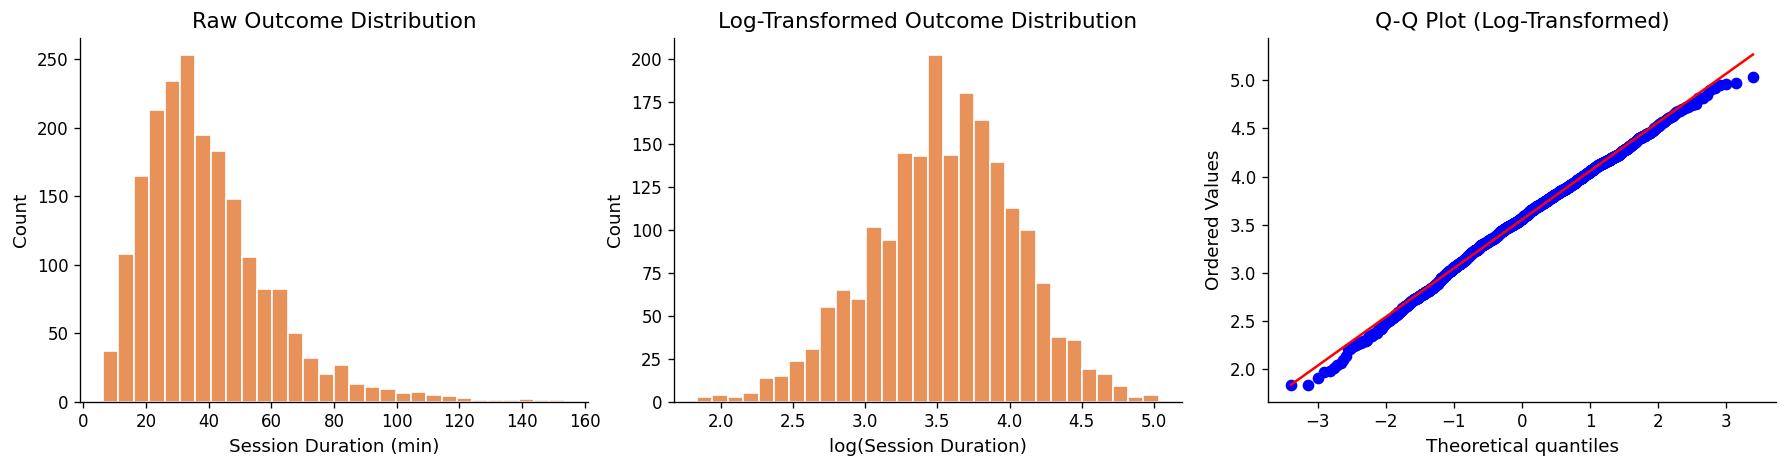

Raw skewness:          1.3758
Log-transformed skewness: -0.2133


In [ ]:
y = df_ab['avg_whiteboard_session_duration_min']
log_y = np.log(y)

# 1. Normality & Transformation Visualizations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(y, bins=30, color=ACCENT, edgecolor='white')
axes[0].set_title('Raw Outcome Distribution')
axes[0].set_xlabel('Session Duration (min)')
axes[0].set_ylabel('Count')

axes[1].hist(log_y, bins=30, color=ACCENT, edgecolor='white')
axes[1].set_title('Log-Transformed Outcome Distribution')
axes[1].set_xlabel('log(Session Duration)')
axes[1].set_ylabel('Count')

stats.probplot(log_y, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Log-Transformed)')

plt.tight_layout()
plt.show()

# 2. Statistical Diagnostics
print(f"Raw skewness:          {stats.skew(y):.4f}")
print(f"Log-transformed skewness: {stats.skew(log_y):.4f}")


**✏️ Your interpretation (A1.1):**

The raw outcome () is right-skewed with a skewness of 1.38, indicating a long right tail driven by a small number of very long sessions. After applying a natural log transformation, the skewness drops to −0.21, which is very close to zero and reflects a nearly symmetric distribution. The Q-Q plot of the log-transformed outcome shows the quantiles falling tightly along the theoretical normal line, with only minor deviations at the tails, confirming approximate normality. I will use the log-transformed outcome in the OLS model, as the normality of residuals assumption is much better satisfied on that scale.


#### A1.2 — Examine the confounders

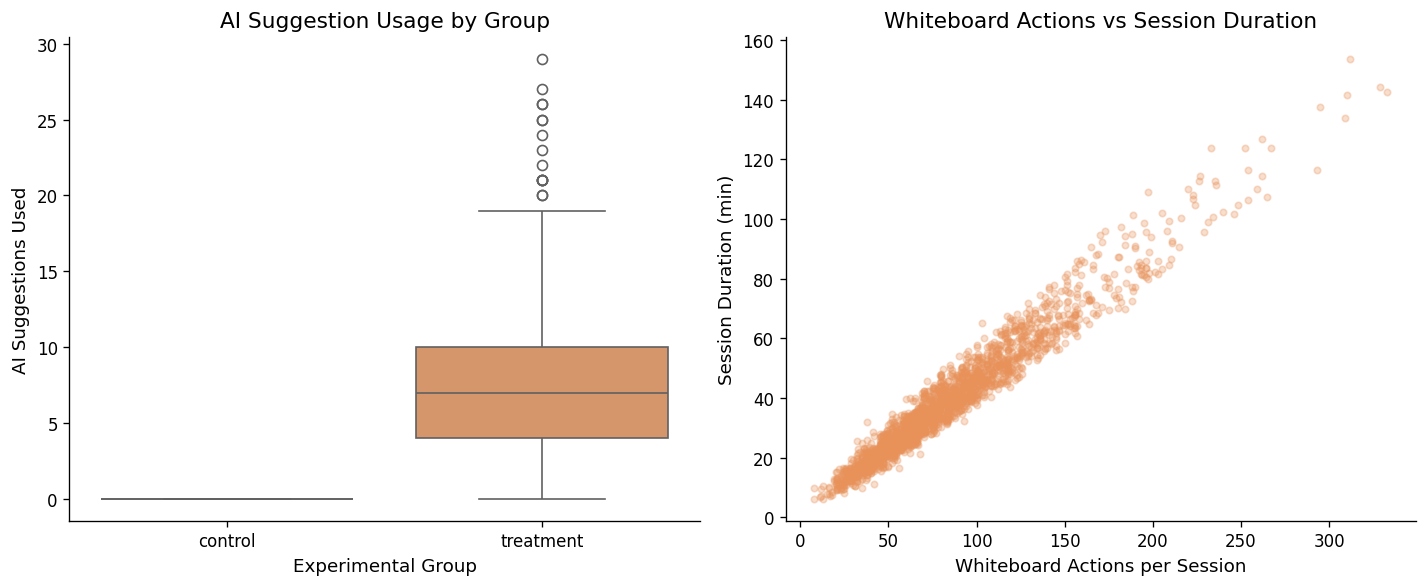

Correlation (whiteboard_actions_per_session vs outcome): 0.9737

AI suggestions used — descriptive stats by group:
            count  mean   std  min  25%  50%   75%   max
ab_group                                                
control    1011.0  0.00  0.00  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.33  4.55  0.0  4.0  7.0  10.0  29.0


In [8]:
# 1. Visual Exploratory Data Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df_ab, x='ab_group', y='ai_suggestions_used',
    palette={'control': '#aec6cf', 'treatment': ACCENT}, ax=axes[0]
)
axes[0].set_title('AI Suggestion Usage by Group')
axes[0].set_xlabel('Experimental Group')
axes[0].set_ylabel('AI Suggestions Used')

axes[1].scatter(
    df_ab['whiteboard_actions_per_session'],
    df_ab['avg_whiteboard_session_duration_min'],
    alpha=0.3, color=ACCENT, s=15
)
axes[1].set_title('Whiteboard Actions vs Session Duration')
axes[1].set_xlabel('Whiteboard Actions per Session')
axes[1].set_ylabel('Session Duration (min)')

plt.tight_layout()
plt.show()

# 2. Statistical Analysis
corr = df_ab['whiteboard_actions_per_session'].corr(df_ab['avg_whiteboard_session_duration_min'])
print(f"Correlation (whiteboard_actions_per_session vs outcome): {corr:.4f}")
print()
print("AI suggestions used — descriptive stats by group:")
print(df_ab.groupby('ab_group')['ai_suggestions_used'].describe().round(2))


**✏️ Your interpretation (A1.2):**

  ai_suggestions_used is zero for every control user and averages 7.33 in the treatment group, so it is basically just another name for the treatment itself. If we add it as a predictor, it overlaps almost perfectly with the group variable and ends up soaking up the treatment effect we are trying to measure. whiteboard_actions_per_session correlates 0.97 with the outcome, which means it is essentially measuring the same thing as session duration rather than explaining it. Including it would overlap heavily with the outcome and make the treatment coefficient unreliable. Both variables are dropped because they either restate the outcome or are results of the treatment, not characteristics users had beforehand.


#### A1.3 — Predictor distributions and relationships with outcome

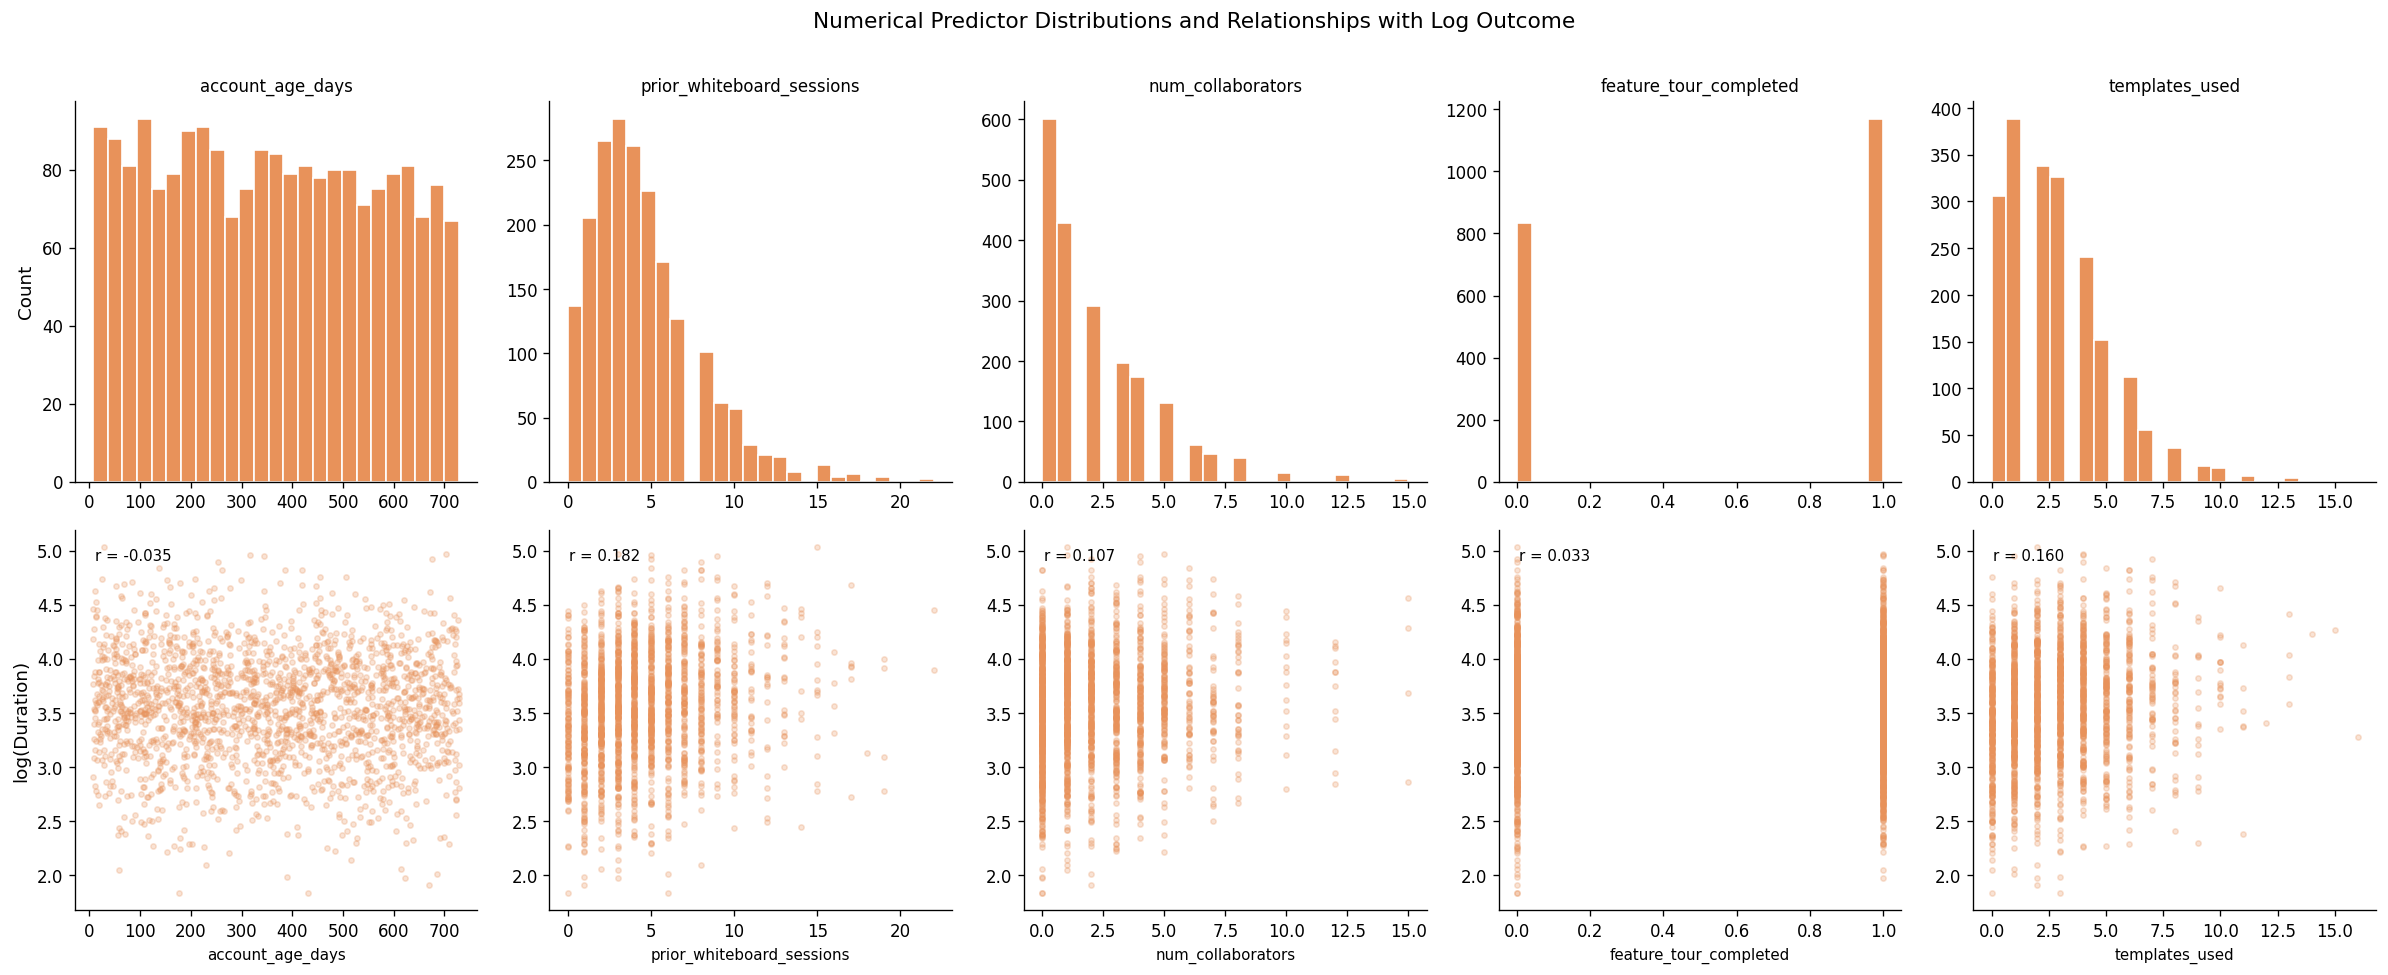

In [ ]:
num_predictors = ['account_age_days', 'prior_whiteboard_sessions', 'num_collaborators',
                  'feature_tour_completed', 'templates_used']
log_y = np.log(df_ab['avg_whiteboard_session_duration_min'])

n = len(num_predictors)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

for j, col in enumerate(num_predictors):
    # Top row: histogram
    axes[0, j].hist(df_ab[col], bins=25, color=ACCENT, edgecolor='white')
    axes[0, j].set_title(col, fontsize=10)
    axes[0, j].set_ylabel('Count' if j == 0 else '')

    # Bottom row: scatter vs log outcome
    corr = df_ab[col].corr(log_y)
    axes[1, j].scatter(df_ab[col], log_y, alpha=0.25, s=10, color=ACCENT)
    axes[1, j].set_xlabel(col, fontsize=9)
    axes[1, j].set_ylabel('log(Duration)' if j == 0 else '')
    axes[1, j].annotate(f'r = {corr:.3f}', xy=(0.05, 0.92),
                        xycoords='axes fraction', fontsize=9)

fig.suptitle('Numerical Predictor Distributions and Relationships with Log Outcome',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


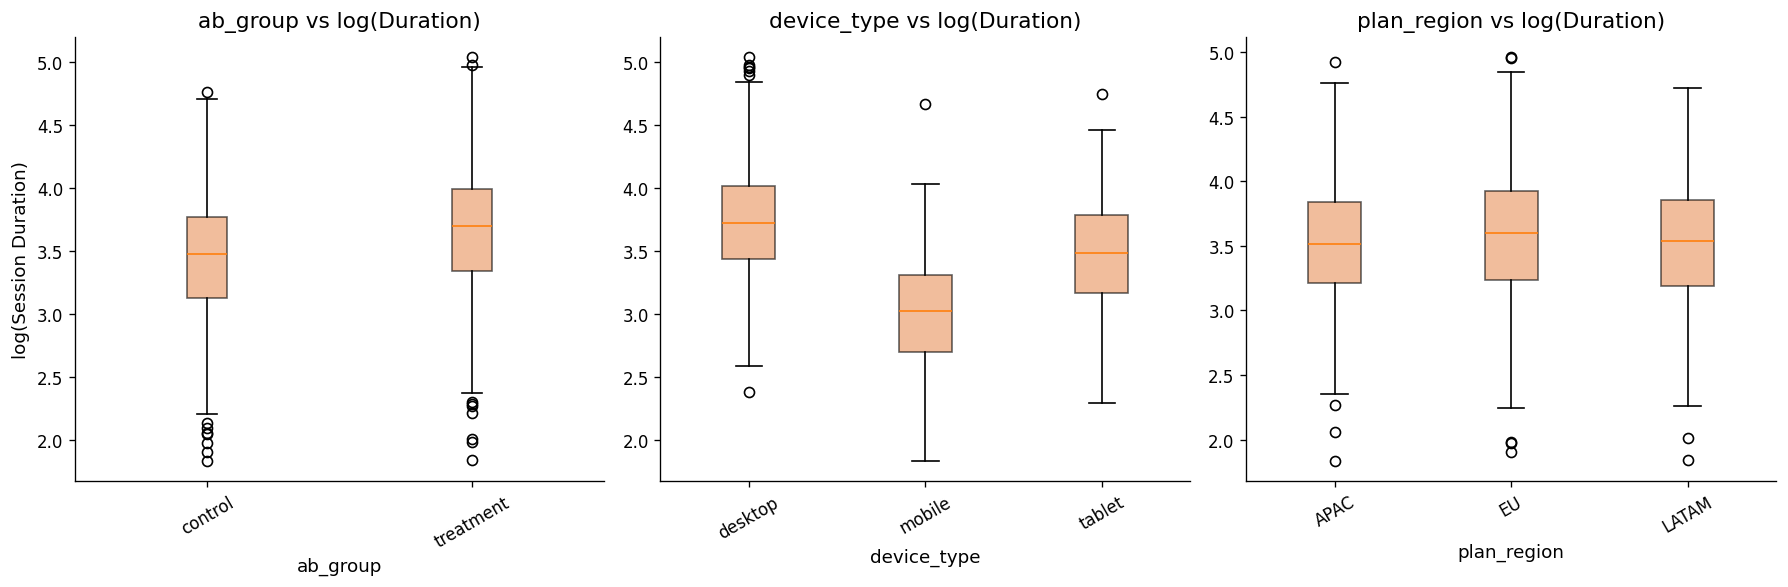

In [ ]:
cat_predictors = ['ab_group', 'device_type', 'plan_region']

n = len(cat_predictors)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

for j, col in enumerate(cat_predictors):
    levels = sorted(df_ab[col].dropna().unique())
    groups = [log_y[df_ab[col] == lvl] for lvl in levels]
    axes[j].boxplot(groups, labels=levels, patch_artist=True,
                    boxprops=dict(facecolor=ACCENT, alpha=0.6))
    axes[j].set_title(f'{col} vs log(Duration)')
    axes[j].set_xlabel(col)
    axes[j].set_ylabel('log(Session Duration)' if j == 0 else '')
    axes[j].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**✏️ Your interpretation (A1.3):**

Among the numerical predictors, prior_whiteboard_sessions (r = 0.182), templates_used (r = 0.160), and num_collaborators (r = 0.107) show the strongest positive correlations with the log-transformed outcome, making them the most promising features for the model. account_age_days (r = -0.035) and feature_tour_completed (r = 0.033) have near-zero correlations and are unlikely to add much predictive power. prior_whiteboard_sessions and templates_used are both right-skewed and are good candidates for a log(x + 1) transformation before use as predictors. Among the categoricals, ab_group shows a visible upward median shift from control to treatment, confirming it captures the intervention effect, while device_type shows desktop sessions running longer than mobile, and plan_region looks broadly similar across regions. The two excluded variables are ai_suggestions_used (zero for all control users, so it is effectively a restatement of the treatment group) and whiteboard_actions_per_session (r = 0.97 with the outcome, a near-duplicate of what we are trying to predict).


### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


In [ ]:
# 1. Encode Categorical Variables
df_ab['ab_group_bin'] = (df_ab['ab_group'] == 'treatment').astype(int)

device_dummies = pd.get_dummies(df_ab['device_type'], prefix='device', drop_first=True)
region_dummies = pd.get_dummies(df_ab['plan_region'], prefix='region', drop_first=True)

# 2. Perform Optional Transformations
df_ab['log_prior_whiteboard_sessions'] = np.log1p(df_ab['prior_whiteboard_sessions'])
df_ab['log_templates_used'] = np.log1p(df_ab['templates_used'])

# 3. Assemble Modeling Dataset
X = pd.concat([
    df_ab[['account_age_days', 'log_prior_whiteboard_sessions', 'num_collaborators',
           'feature_tour_completed', 'log_templates_used', 'ab_group_bin']],
    device_dummies,
    region_dummies,
], axis=1)

y = np.log(df_ab['avg_whiteboard_session_duration_min'])

# 4. Quality Control
print(f'X shape: {X.shape}')
print(f'Missing values in X: {X.isnull().sum().sum()}')
print()
print(X.head())


X shape: (2000, 10)
Missing values in X: 0

   account_age_days  log_prior_whiteboard_sessions  num_collaborators  \
0               478                       1.609438                  3   
1               633                       2.302585                  1   
2               159                       2.397895                  5   
3                 7                       1.791759                  1   
4                44                       1.386294                  0   

   feature_tour_completed  log_templates_used  ab_group_bin  device_mobile  \
0                       1            0.000000             0          False   
1                       0            0.693147             0          False   
2                       1            0.693147             0          False   
3                       0            1.098612             0          False   
4                       1            1.791759             0           True   

   device_tablet  region_EU  region_LATAM  
0   

In [15]:
from scipy.stats import skew

for col in ['account_age_days', 'prior_whiteboard_sessions',
            'num_collaborators', 'templates_used']:
    print(f"{col}: skewness = {skew(df_ab[col]):.2f}")

account_age_days: skewness = 0.06
prior_whiteboard_sessions: skewness = 1.20
num_collaborators: skewness = 1.55
templates_used: skewness = 1.16


**Your interpretation (A2):**

The final feature matrix X contains the following columns:

- account_age_days: included as-is; near-zero skewness (0.06) means no transformation is needed.
- log_prior_whiteboard_sessions: log-transformed with np.log1p because prior_whiteboard_sessions is right-skewed (skewness 1.20) and contains zeros, where np.log would produce -inf.
- num_collaborators: included as-is; right-skewed (skewness 1.55) but kept on the raw scale as its correlation with the outcome is modest (r = 0.107).
- feature_tour_completed: included as-is; binary 0/1 flag, no transformation needed.
- log_templates_used: log-transformed with np.log1p because templates_used is right-skewed (skewness 1.16) and contains zeros.
- ab_group_bin: encoded as 1 = treatment, 0 = control; this is the key causal variable of interest.
- device_mobile, device_tablet: one-hot encoding of device_type with the first level (desktop) dropped to avoid the dummy-variable trap.
- region_EU, region_LATAM: one-hot encoding of plan_region with the first level (APAC) dropped to avoid the dummy-variable trap.

ai_suggestions_used and whiteboard_actions_per_session are excluded: the former is effectively a proxy for the treatment group (zero for all control users), and the latter is a near-duplicate of the outcome (r = 0.97).


### A3 — OLS Regression


In [ ]:
# YOUR CODE HERE
# Add a constant for the intercept, then fit OLS
X_const = sm.add_constant(X)
model_ols = sm.OLS(y, X_const).fit()
print(model_ols.summary())


#### A3.1 — Interpret the model

In [ ]:
BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

**✏️ Results paragraph (A3):**

*Write a results paragraph as if reporting in a research paper. Include:*
- *The treatment effect estimate and its significance*
- *R² and what it tells you about model fit*
- *At least two other notable predictors and their direction*
- *Whether the AI assistant's effect is practically meaningful (not just statistically significant)*


#### A3.2 — Regression diagnostics

In [ ]:
BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line
    
    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*


In [ ]:
# YOUR CODE HERE
# Step 1: Create the interaction term
# Example: df_ab['ab_x_device_desktop'] = df_ab['ab_group_enc'] * df_ab['device_desktop']

# Step 2: Add the interaction term to your feature matrix and refit OLS
# X_interact = pd.concat([X_const, interaction_col], axis=1)
# model_interact = sm.OLS(y, X_interact).fit()
# print(model_interact.summary())


In [ ]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines


**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*


---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [ ]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)


In [ ]:
df_sub.describe(include='all').round(2)


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [ ]:
# YOUR CODE HERE

# 1. Parse dates
# df_sub['signup_date'] = pd.to_datetime(df_sub['signup_date'])
# df_sub['first_session_date'] = pd.to_datetime(df_sub['first_session_date'])

# 2. days_to_first_session
# df_sub['days_to_first_session'] = (df_sub['first_session_date'] - df_sub['signup_date']).dt.days

# 3. avg_session_duration_min — handle divide-by-zero explicitly
# df_sub['avg_session_duration_min'] = ...

# 4. is_weekend_signup (1 if Saturday=5 or Sunday=6)
# df_sub['is_weekend_signup'] = df_sub['signup_date'].dt.weekday.isin([5, 6]).astype(int)

# 5. One-hot encode device_type (drop first level)
# device_dummies2 = pd.get_dummies(df_sub['device_type'], prefix='device', drop_first=True)

# 6. One-hot encode referral_source (drop first level)
# referral_dummies = pd.get_dummies(df_sub['referral_source'], prefix='ref', drop_first=True)

# 7. Encode country_tier — ordinal or one-hot (justify below)
# Option A (ordinal): df_sub['country_tier_enc'] = df_sub['country_tier'].map({'tier_1':1,'tier_2':2,'tier_3':3})
# Option B (one-hot): pd.get_dummies(...)

# 8. Assemble final feature matrix
# Drop: user_id, signup_date, first_session_date, device_type, referral_source, country_tier, subscribed
# X_sub = pd.concat([...], axis=1)
# y_sub = df_sub['subscribed']

# Confirm
# print(f"Any inf: {np.isinf(X_sub.values).any()}")
# print(f"Any NaN: {X_sub.isnull().any().any()}")
# print(f"Feature matrix shape: {X_sub.shape}")
# X_sub.head(3)


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*


### B2 — EDA for Subscription


In [ ]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


In [ ]:
# YOUR CODE HERE
# Visualize subscription rates across at least 3 features
# Suggestions:
#   - Bar chart: subscription rate by referral_source
#   - Bar chart: subscription rate by country_tier
#   - Boxplot: exports_30d distribution by subscribed (0 vs 1)
#   - Bar chart: subscription rate by used_premium_feature_preview
#   - Any other feature you find interesting

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 — YOUR CODE
# axes[0]: ...

# Plot 2 — YOUR CODE
# axes[1]: ...

# Plot 3 — YOUR CODE
# axes[2]: ...

plt.tight_layout()
plt.show()


In [ ]:
# YOUR CODE HERE
# Correlation matrix of numeric features (exclude user_id and binary outcome)
# numeric_features = X_sub.select_dtypes(include='number').columns.tolist()
# corr = X_sub[numeric_features].corr()
# Plot as heatmap


**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*


### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [ ]:
# YOUR CODE HERE
# X_const_sub = sm.add_constant(X_sub)
# model_logit = sm.Logit(y_sub, X_const_sub).fit()
# print(model_logit.summary())


In [ ]:
# YOUR CODE HERE
# Compute odds ratios for all significant predictors (p < 0.05)
# odds_ratios = np.exp(model_logit.params)
# conf_int    = np.exp(model_logit.conf_int())
# Combine into a readable table and display
# Filter to significant only: p < 0.05


In [ ]:
# YOUR CODE HERE
# Visualize odds ratios as a horizontal bar chart (forest plot style)
# Show confidence intervals if possible
# Order bars by magnitude


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*


### B4 — Logistic Regression with sklearn (Predictive)


In [ ]:
# YOUR CODE HERE
# Train/test split — use these exact parameters so Part C comparisons are valid
# X_train, X_test, y_train, y_test = train_test_split(
#     X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
# )
# print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
# print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")


In [ ]:
# YOUR CODE HERE
# Fit sklearn LogisticRegression
# clf_lr = LogisticRegression(max_iter=1000, random_state=42)
# clf_lr.fit(X_train, y_train)
# y_pred_lr = clf_lr.predict(X_test)
# y_prob_lr = clf_lr.predict_proba(X_test)[:, 1]


In [ ]:
# YOUR CODE HERE
# Confusion matrix heatmap
# cm_lr = confusion_matrix(y_test, y_pred_lr)
# disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not subscribed', 'Subscribed'])
# fig, ax = plt.subplots(figsize=(5, 4))
# disp.plot(ax=ax, cmap='Blues', colorbar=False)
# plt.title('Logistic Regression — Confusion Matrix')
# plt.show()


In [ ]:
# YOUR CODE HERE
# Classification report
# print(classification_report(y_test, y_pred_lr, target_names=['Not subscribed', 'Subscribed']))
# print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

# fig, ax = plt.subplots(figsize=(6, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8)
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve — Logistic Regression')
# ax.legend()
# plt.show()


**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Model name here]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*


### C2 — Fit and Evaluate


In [ ]:
# YOUR CODE HERE
# Import your chosen model, e.g.:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.svm import SVC
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
# from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
# from xgboost import XGBClassifier  # pip install xgboost
# from lightgbm import LGBMClassifier  # pip install lightgbm

# Fit with default hyperparameters
# clf_c = YourModel(random_state=42)   # add random_state if supported
# clf_c.fit(X_train, y_train)
# y_pred_c = clf_c.predict(X_test)
# y_prob_c = clf_c.predict_proba(X_test)[:, 1]  # omit if model has no predict_proba (e.g. SVM)


In [ ]:
# YOUR CODE HERE
# Confusion matrix


In [ ]:
# YOUR CODE HERE
# Classification report + ROC-AUC


In [ ]:
# YOUR CODE HERE
# ROC curve (save fpr_c, tpr_c, auc_c for comparison plot)


### C3 — Model Comparison


In [ ]:
# YOUR CODE HERE
# Summary comparison table
# metrics = {
#     'Model': ['Logistic Regression', 'YOUR MODEL NAME'],
#     'ROC-AUC': [...],
#     'F1 (class 1)': [...],
#     'Precision (class 1)': [...],
#     'Recall (class 1)': [...],
# }
# pd.DataFrame(metrics).set_index('Model').round(4)


In [ ]:
# YOUR CODE HERE
# Dual ROC curve plot
# fig, ax = plt.subplots(figsize=(7, 5))
# ax.plot(fpr_lr, tpr_lr, color=ACCENT, lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
# ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'YOUR MODEL (AUC={auc_c:.3f})')
# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve Comparison')
# ax.legend()
# plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [ ]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV

# Define a parameter grid relevant to your chosen model
# param_grid = { ... }

# Run cross-validated search on the TRAINING SET ONLY
# search = GridSearchCV(YourModel(), param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
# search.fit(X_train, y_train)

# print(f"Best parameters: {search.best_params_}")
# print(f"Best CV AUC:     {search.best_score_:.4f}")

# Evaluate tuned model on test set
# y_pred_tuned = search.best_estimator_.predict(X_test)
# y_prob_tuned = search.best_estimator_.predict_proba(X_test)[:, 1]
# print(f"Tuned test AUC:  {roc_auc_score(y_test, y_prob_tuned):.4f}")
# print(f"Default test AUC:{auc_c:.4f}")
# print("Did tuning meaningfully improve results? [Your one sentence here]")


---

## Submission Checklist

Before submitting, confirm:

- [ ] All `# YOUR CODE HERE` cells are completed and run without errors
- [ ] All `**✏️ Your interpretation**` cells contain your own written analysis
- [ ] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [ ] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [ ] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [ ] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
